# Denoising Pipeline

This notebook trains and evaluates multiple neural network architectures (MLP, 1D CNN, 1D UNet) and preprocessing strategies (Standard, MinMax, LogMinMax) for denoising X-ray Fluorescence (XRF) spectra.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', '..')))

import numpy as np
import matplotlib.pyplot as plt
import torch
from src.data.denoising.generator import DenoisingDataGenerator
from src.data.common.base_generator import GeneratorConfig
from src.models.denoising.preprocessing import StandardScaler, MinMaxScaler, LogMinMaxScaler
from src.models.denoising.architectures import MLPAutoencoder, CNNAutoencoder, UNet1D, TransformerAutoencoder, ConformerAutoencoder, ResNet1DAutoencoder, LSTMAutoencoder, LinearAutoencoder
from src.models.denoising.trainer import DenoisingTrainer

np.random.seed(42)
torch.manual_seed(42)

## 0. Hardware Check
Let's check if a GPU is available and which one is being used.

In [2]:
print(f"PyTorch version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("No GPU detected. Training will proceed on CPU (this may be slow).")

PyTorch version: 2.10.0+cu128
Using device: cuda
GPU Name: NVIDIA GeForce RTX 4060
GPU Memory: 7.61 GB


## 1. Data Generation
We generate 2000 paired samples using the `DenoisingDataGenerator`. The config is set to generate highly noisy inputs.

In [3]:
generator = DenoisingDataGenerator()
config = GeneratorConfig.Presets.denoising()

num_samples = 2000
noisy_data, clean_data = generator.generate_dataset(num_samples=num_samples, config=config, num_workers=12)

print(f"Generated data shape: {noisy_data.shape}")

Starting parallel generation with 12 workers...


Parallel Generation: 100%|██████████| 2000/2000 [02:35<00:00, 12.88it/s]


Generated data shape: (2000, 600)


## 2. Train / Val / Test Split
We split the data 70/15/15.

In [4]:
indices = np.arange(num_samples)
np.random.shuffle(indices)
noisy_data = noisy_data[indices]
clean_data = clean_data[indices]

train_split = int(0.7 * num_samples)
val_split = int(0.85 * num_samples)

X_train_noisy, y_train_clean = noisy_data[:train_split], clean_data[:train_split]
X_val_noisy, y_val_clean = noisy_data[train_split:val_split], clean_data[train_split:val_split]
X_test_noisy, y_test_clean = noisy_data[val_split:], clean_data[val_split:]

print(f"Train size: {X_train_noisy.shape[0]}")
print(f"Val size: {X_val_noisy.shape[0]}")
print(f"Test size: {X_test_noisy.shape[0]}")

Train size: 1400
Val size: 300
Test size: 300


## 3. Experimental Grid & Training
We loop through our defined preprocessing strategies and architectures, training a model for each combination.

In [5]:
preprocessing_strategies = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'LogMinMax': LogMinMaxScaler()
}

architectures = {
    'MLP': MLPAutoencoder,
    'CNN': CNNAutoencoder,
    'UNet': UNet1D,
    'Transformer': TransformerAutoencoder,
    'Conformer': ConformerAutoencoder,
    'ResNet1D': ResNet1DAutoencoder,
    'LSTM': LSTMAutoencoder,
    'Linear': LinearAutoencoder
}

results = {}
trained_models = {}

In [6]:
epochs = 500
batch_size = 64
patience = 20
input_dim = noisy_data.shape[1]

for prep_name, scaler in preprocessing_strategies.items():
    print(f"\n{'='*40}")
    print(f"Preprocessing Strategy: {prep_name}")
    print(f"{'='*40}")
    
    # 1. Apply Scaler (fit on clean train data, transform all)
    scaler.fit(y_train_clean)
    
    X_train_scaled = scaler.transform(X_train_noisy)
    y_train_scaled = scaler.transform(y_train_clean)
    
    X_val_scaled = scaler.transform(X_val_noisy)
    y_val_scaled = scaler.transform(y_val_clean)
    
    X_test_scaled = scaler.transform(X_test_noisy)
    y_test_scaled = scaler.transform(y_test_clean)
    
    for arch_name, ArchClass in architectures.items():
        print(f"\n--> Training Model: {arch_name}")
        
        # Initialize model
        model = ArchClass(input_dim=input_dim)
        trainer = DenoisingTrainer(model=model, learning_rate=1e-3)
        
        # Train
        history = trainer.train(
            X_train_scaled, y_train_scaled,
            X_val_scaled, y_val_scaled,
            epochs=epochs,
            batch_size=batch_size,
            patience=patience
        )
        
        # Evaluate on TEST set in SCALED space
        metrics_scaled = trainer.evaluate_metrics(X_test_scaled, y_test_scaled)
        
        # Evaluate on TEST set in ORIGINAL space
        preds_scaled = trainer.predict(X_test_scaled)
        preds_original = scaler.inverse_transform(preds_scaled)
        
        mse_orig = np.mean((preds_original - y_test_clean)**2)
        mae_orig = np.mean(np.abs(preds_original - y_test_clean))
        
        results[f"{prep_name}_{arch_name}"] = {
            'mse_scaled': metrics_scaled['MSE'],
            'mae_scaled': metrics_scaled['MAE'],
            'mse_orig': mse_orig,
            'mae_orig': mae_orig,
            'history': history
        }
        
        # Store trainer and scaler for final plots
        trained_models[f"{prep_name}_{arch_name}"] = (trainer, scaler)

        print(f"Test MSE (Original Scale): {mse_orig:.2e} | MAE: {mae_orig:.2e}")


Preprocessing Strategy: Standard

--> Training Model: MLP


Training:   5%|▌         | 26/500 [00:00<00:14, 31.79it/s, train_loss=3.71e-01, val_loss=2.89e+00]


Early stopping triggered at epoch 27
Test MSE (Original Scale): 5.73e-05 | MAE: 1.82e-03

--> Training Model: CNN


Training:   9%|▉         | 46/500 [00:01<00:15, 29.68it/s, train_loss=6.13e-01, val_loss=2.73e+00]


Early stopping triggered at epoch 47
Test MSE (Original Scale): 3.86e-05 | MAE: 1.35e-03

--> Training Model: UNet


...

Early stopping triggered at epoch 106
Test MSE (Original Scale): 4.81e-05 | MAE: 1.63e-03

--> Training Model: LSTM


Training:   8%|▊         | 39/500 [00:04<00:54,  8.53it/s, train_loss=3.26e-03, val_loss=6.61e-03]


Early stopping triggered at epoch 40
Test MSE (Original Scale): 4.24e-05 | MAE: 1.23e-03

--> Training Model: Linear


Training:   7%|▋         | 33/500 [00:00<00:07, 61.02it/s, train_loss=2.38e-03, val_loss=6.66e-03]

Early stopping triggered at epoch 34
Test MSE (Original Scale): 4.70e-05 | MAE: 1.66e-03


In [21]:
TO_SAVE_IMAGES = False
PATH_TO_SAVE_IMAGES = 'src/denoising/media/'

if TO_SAVE_IMAGES:
    # Check if directory exists, if not create it
    if not os.path.exists(PATH_TO_SAVE_IMAGES):
        os.makedirs(PATH_TO_SAVE_IMAGES)

## 4. Training Loss Visualization
We plot the validation loss for each architecture to visualize convergence and the effect of Early Stopping.

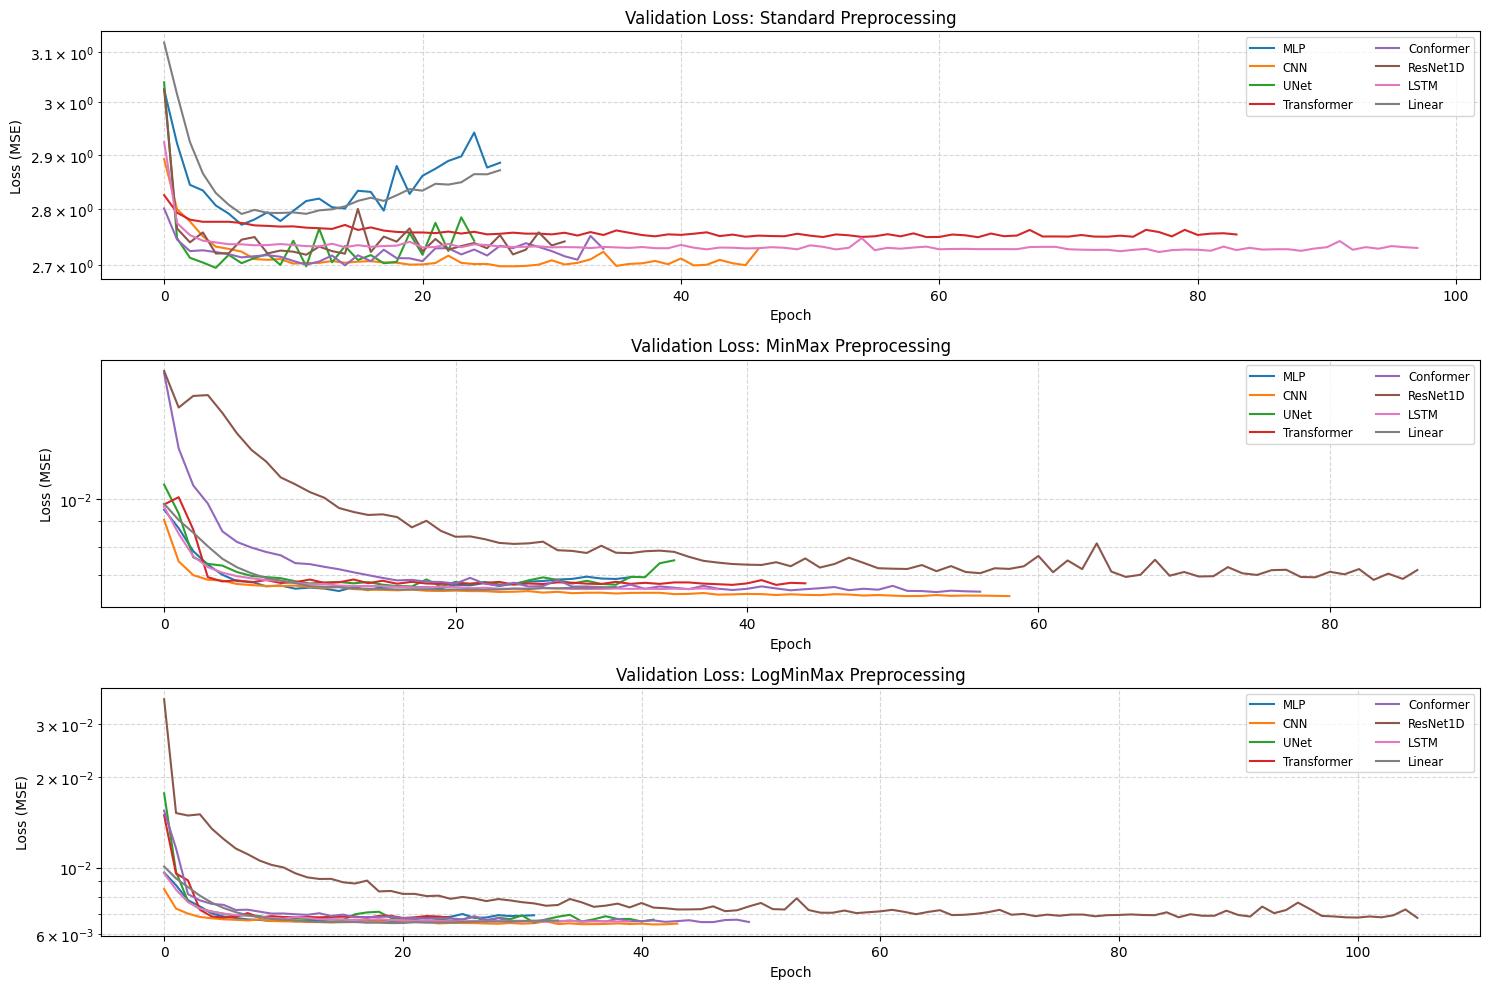

In [ ]:
plt.figure(figsize=(15, 10))

plot_idx = 1
for prep_name in preprocessing_strategies.keys():
    plt.subplot(len(preprocessing_strategies), 1, plot_idx)
    for arch_name in architectures.keys():
        key = f"{prep_name}_{arch_name}"
        if key in results:
            history = results[key]['history']
            plt.plot(history['val_loss'], label=f"{arch_name}")
    
    plt.title(f"Validation Loss: {prep_name} Preprocessing")
    plt.yscale('log')
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend(loc='upper right', ncol=2, fontsize='small')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plot_idx += 1

plt.tight_layout()
if TO_SAVE_IMAGES:
    plt.savefig(f'{PATH_TO_SAVE_IMAGES}/training_loss.png')
plt.show()

## 5. Evaluation & Visualization
Let's compare the reconstructions visually for a single test sample.

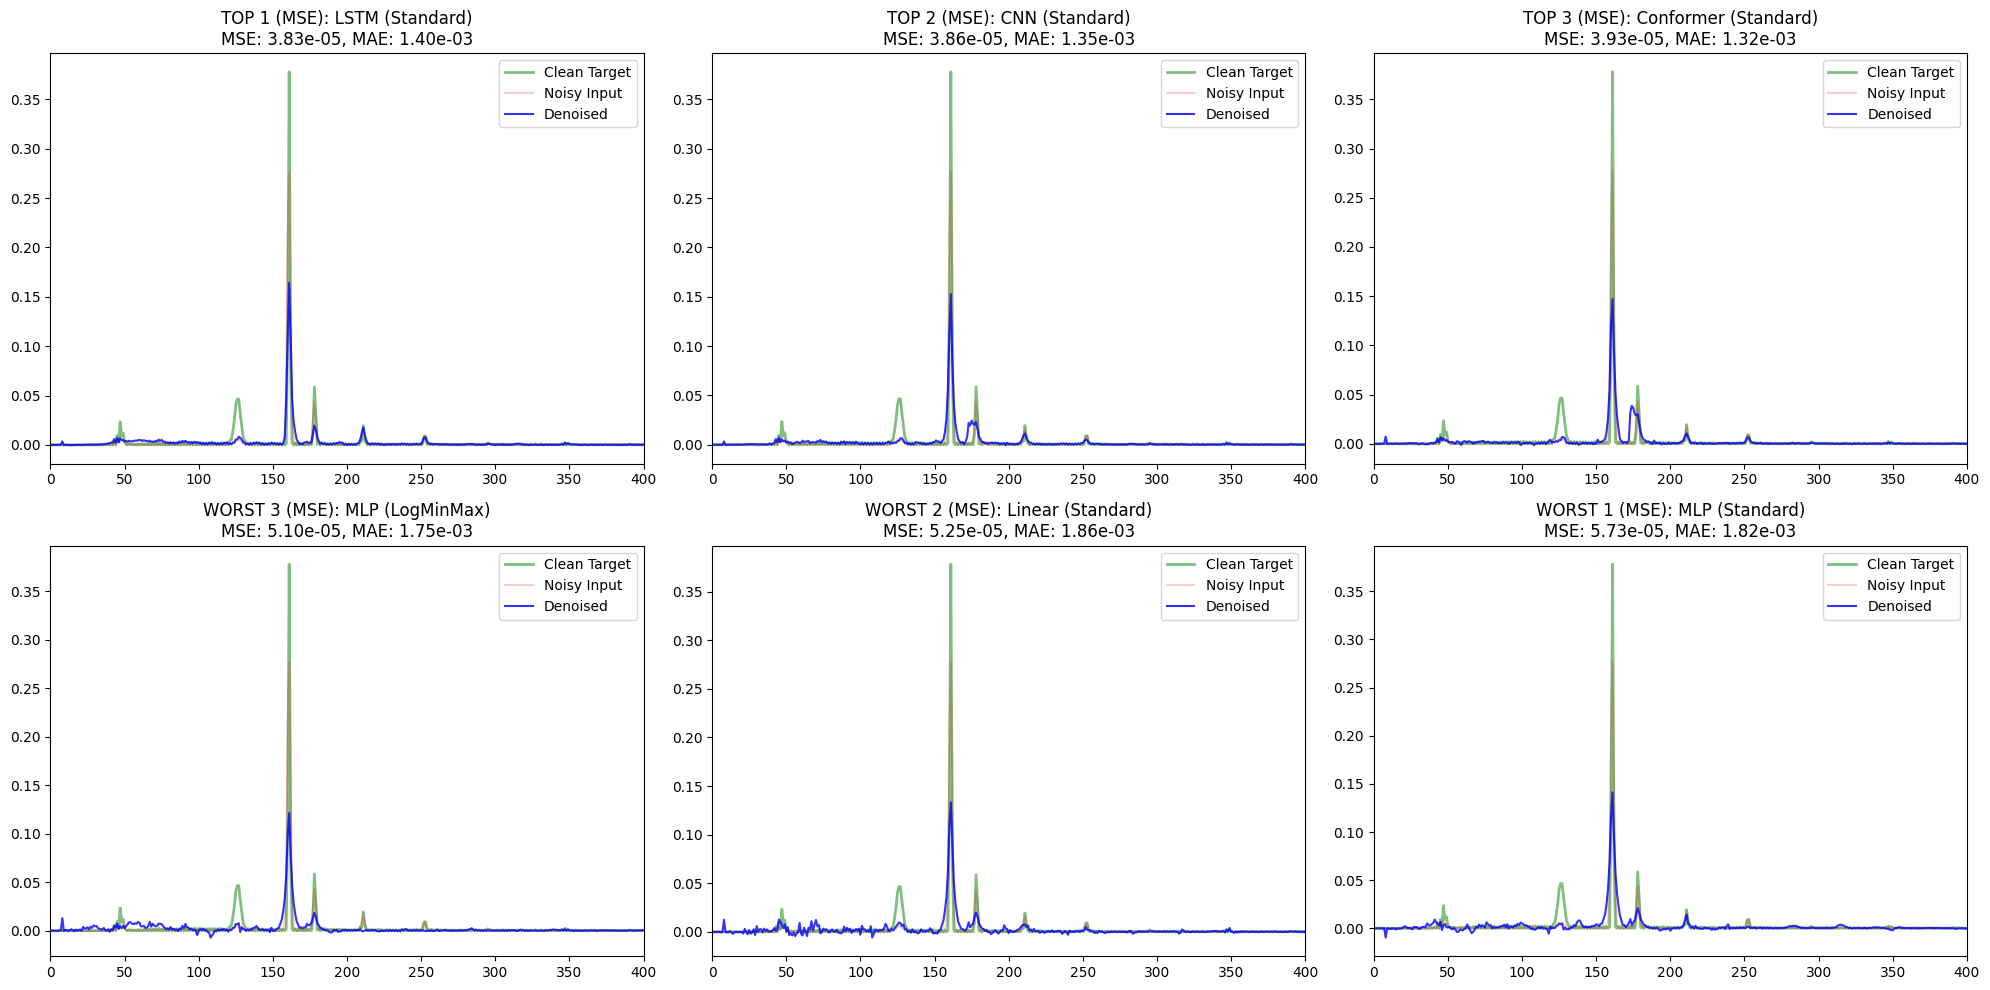

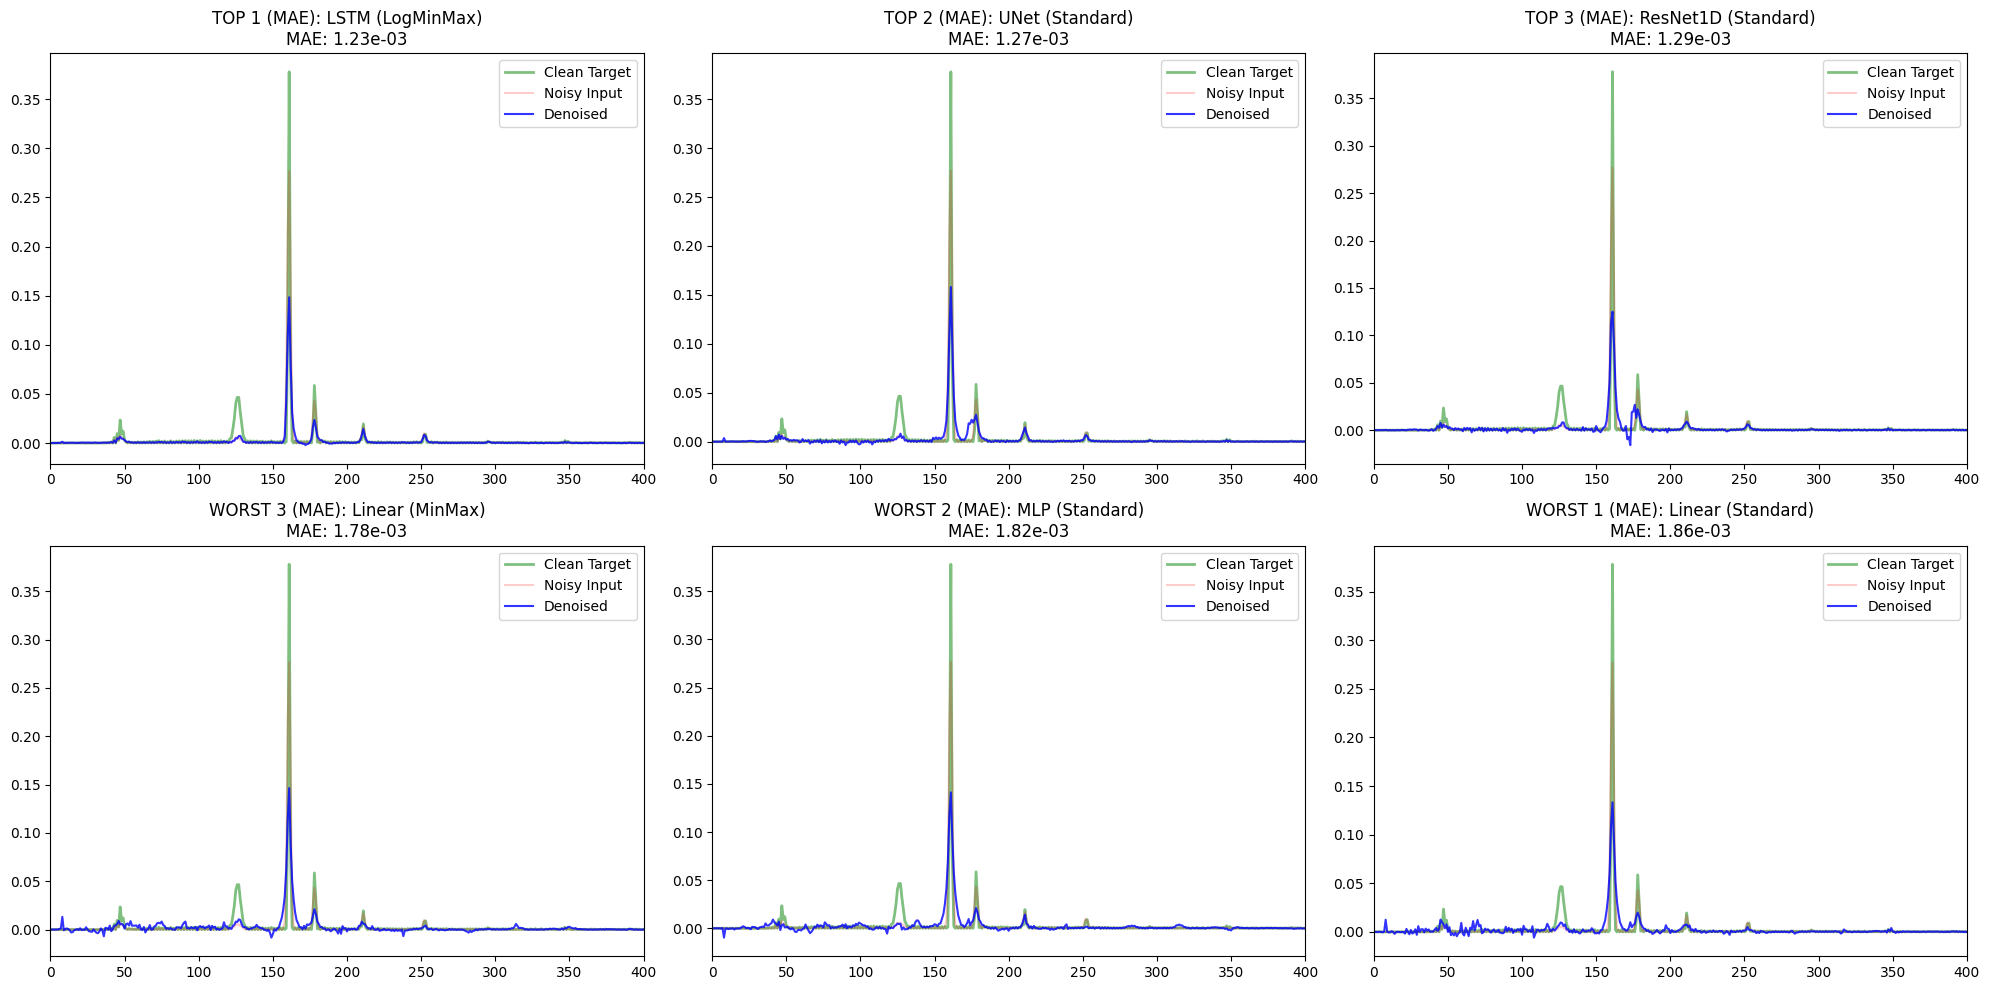

In [28]:
sorted_keys_mse = sorted(results.keys(), key=lambda k: results[k]['mse_orig'])
top_k_mse = sorted_keys_mse[:3]
worst_k_mse = sorted_keys_mse[-3:]
compare_keys_mse = top_k_mse + worst_k_mse

plt.figure(figsize=(20, 10))
sample_idx = 0
test_noisy_sample = X_test_noisy[sample_idx:sample_idx+1]
test_clean_sample = y_test_clean[sample_idx:sample_idx+1]

for i, key in enumerate(compare_keys_mse):
    if i < 3:
        title_prefix = f"TOP {i+1} (MSE)"
    else:
        title_prefix = f"WORST {6-i} (MSE)"
        
    trainer, scaler = trained_models[key]
    parts = key.split('_')
    prep_name, arch_name = parts[0], parts[1]
    
    scaled_input = scaler.transform(test_noisy_sample)
    scaled_pred = trainer.predict(scaled_input)
    pred_orig = scaler.inverse_transform(scaled_pred)[0]
    
    plt.subplot(2, 3, i+1)
    plt.plot(test_clean_sample[0], label='Clean Target', color='green', alpha=0.5, lw=2)
    plt.plot(test_noisy_sample[0], label='Noisy Input', color='red', alpha=0.2)
    plt.plot(pred_orig, label='Denoised', color='blue', alpha=0.8)
    plt.title(f"{title_prefix}: {arch_name} ({prep_name})\nMSE: {results[key]['mse_orig']:.2e}, MAE: {results[key]['mae_orig']:.2e}")
    plt.legend()
    plt.xlim(0, 400)
plt.tight_layout()
if TO_SAVE_IMAGES:
    plt.savefig(f'{PATH_TO_SAVE_IMAGES}/top_worst_mse_k3.png')
plt.show()

# Duplicated for MAE sorting
sorted_keys_mae = sorted(results.keys(), key=lambda k: results[k]['mae_orig'])
top_k_mae = sorted_keys_mae[:3]
worst_k_mae = sorted_keys_mae[-3:]
compare_keys_mae = top_k_mae + worst_k_mae

plt.figure(figsize=(20, 10))
for i, key in enumerate(compare_keys_mae):
    if i < 3:
        title_prefix = f"TOP {i+1} (MAE)"
    else:
        title_prefix = f"WORST {6-i} (MAE)"
        
    trainer, scaler = trained_models[key]
    parts = key.split('_')
    prep_name, arch_name = parts[0], parts[1]
    
    scaled_input = scaler.transform(test_noisy_sample)
    scaled_pred = trainer.predict(scaled_input)
    pred_orig = scaler.inverse_transform(scaled_pred)[0]
    
    plt.subplot(2, 3, i+1)
    plt.plot(test_clean_sample[0], label='Clean Target', color='green', alpha=0.5, lw=2)
    plt.plot(test_noisy_sample[0], label='Noisy Input', color='red', alpha=0.2)
    plt.plot(pred_orig, label='Denoised', color='blue', alpha=0.8)
    plt.title(f"{title_prefix}: {arch_name} ({prep_name})\nMAE: {results[key]['mae_orig']:.2e}")
    plt.legend()
    plt.xlim(0, 400)
plt.tight_layout()
if TO_SAVE_IMAGES:
    plt.savefig(f'{PATH_TO_SAVE_IMAGES}/top_worst_mae_k3.png')
plt.show()

### 5.2. Save All Sample Plots by Architecture
We save high-resolution comparison plots for every model organized in subdirectories.

In [29]:
if TO_SAVE_IMAGES:
    for key, metrics in results.items():
        trainer, scaler = trained_models[key]
        parts = key.split('_')
        prep_name, arch_name = parts[0], parts[1]
        
        arch_dir = f'{PATH_TO_SAVE_IMAGES}/{arch_name}'
        if not os.path.exists(arch_dir):
            os.makedirs(arch_dir)
        
        scaled_input = scaler.transform(test_noisy_sample)
        scaled_pred = trainer.predict(scaled_input)
        pred_orig = scaler.inverse_transform(scaled_pred)[0]
        
        plt.figure(figsize=(10, 6))
        plt.plot(test_clean_sample[0], label='Clean Target', color='green', alpha=0.5, lw=2)
        plt.plot(test_noisy_sample[0], label='Noisy Input', color='red', alpha=0.2)
        plt.plot(pred_orig, label='Denoised', color='blue', alpha=0.8)
        plt.title(f"{arch_name} with {prep_name} Scaling\nMSE: {metrics['mse_orig']:.2e}, MAE: {metrics['mae_orig']:.2e}")
        plt.legend()
        plt.xlim(0, 400)
        plt.tight_layout()
        
        plt.savefig(f"{arch_dir}/sample_{prep_name}.png")
        plt.close()

## 5. Comparative Results
Finally, we compare all models and preprocessing strategies by sorting them based on their Mean Squared Error (MSE) on the test set.

In [30]:
import pandas as pd

summary_data = []
for key, metrics in results.items():
    # key format: {prep_name}_{arch_name}
    parts = key.split('_')
    prep = parts[0]
    arch = parts[1]
    
    summary_data.append({
        'Preprocessing': prep,
        'Architecture': arch,
        'MSE (Original)': metrics['mse_orig'],
        'MAE (Original)': metrics['mae_orig']
    })

df_results = pd.DataFrame(summary_data).sort_values(by='MSE (Original)')

print("Model Performance Summary (Best to Worst by MSE):")
display(df_results.style.format({
    'MSE (Original)': '{:.2e}',
    'MAE (Original)': '{:.2e}'
}))

Model Performance Summary (Best to Worst by MSE):


,Preprocessing,Architecture,MSE (Original),MAE (Original)
6,Standard,LSTM,3.83e-05,1.40e-03
1,Standard,CNN,3.86e-05,1.35e-03
4,Standard,Conformer,3.93e-05,1.32e-03
2,Standard,UNet,3.96e-05,1.27e-03
14,MinMax,LSTM,4.20e-05,1.32e-03
9,MinMax,CNN,4.21e-05,1.41e-03
18,LogMinMax,UNet,4.24e-05,1.36e-03
22,LogMinMax,LSTM,4.24e-05,1.23e-03
17,LogMinMax,CNN,4.26e-05,1.43e-03
5,Standard,ResNet1D,4.29e-05,1.29e-03
